# Fotogrametría: Reconstrucción 3D de objetos

In [2]:
import os

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import rembg

## Preprocesado

En esta etapa inicial, el objetivo es preparar las imágenes crudas para maximizar la calidad de la reconstrucción 3D. El flujo de trabajo consiste en:

1.  **Carga de Imágenes**: Lectura del dataset original.
2.  **Corrección Gamma**: Aplicamos una expansión de señal (gamma > 1.0) para realzar detalles en zonas de sombra sin saturar las luces. Esto ayuda a que el algoritmo de segmentación distinga mejor el objeto del fondo.
3.  **Eliminación de Fondo (Segmentation)**: Utilizamos `rembg` (basado en U2Net) para generar una máscara de transparencia (canal Alpha). Eliminar el fondo reduce el ruido y evita que se generen puntos 3D erróneos fuera del objeto de interés.
4.  **Guardado**: Las imágenes procesadas se guardan en formato PNG (con transparencia) para ser usadas en las siguientes etapas.

Este preprocesamiento es crítico para asegurar que los algoritmos de detección de características (SIFT) se concentren únicamente en la geometría del objeto.

In [17]:
BASE_PATH = os.path.join('Samples', '04_Samples')
STATE_00 = '00_state'

IMAGES = []
print("Cargando imágenes...")

# Procesamos las imágenes del 01 al 11
for i in range(1, 12):
    filename = f"{i:02d}_model.jpeg"
    file_path = os.path.join(BASE_PATH, STATE_00, filename)
    
    img = cv.imread(file_path, cv.IMREAD_COLOR_RGB)
    img_rgba = cv.cvtColor(img, cv.COLOR_RGB2RGBA)
    IMAGES.append(img_rgba)
    print(f"|-> Cargada imagen: {filename}", end='\r')
print("Imágenes cargadas correctamente.")

Cargando imágenes...
Imágenes cargadas correctamente.g
Imágenes cargadas correctamente.g


### Funciones de Preprocesado

Para automatizar el proceso, definimos dos funciones clave:

*   `apply_gamma(img, g)`: Aplica una transformación de potencia a los píxeles.
    *   Si $g > 1$, la imagen se oscurece, aumentando el contraste en las zonas medias.
    *   Si $g < 1$, la imagen se aclara.
    *   En nuestro caso, buscamos un valor que resalte los bordes del objeto frente al fondo.
*   `remove_background(img_rgba, session, gamma)`: Orquesta el proceso completo para una imagen:
    1.  Separa los canales RGB.
    2.  Aplica la corrección gamma temporalmente para mejorar la detección.
    3.  Pasa la imagen mejorada a `rembg` para obtener la máscara.
    4.  Aplica la máscara a la imagen **original** (sin gamma alterado) para preservar los colores reales de la textura.

Inicializamos la sesión de `rembg` una única vez para evitar la sobrecarga de cargar el modelo neuronal en cada iteración.

In [4]:
# Iniciamos una sesión de rembg que mantendremos todo el tiempo
session = rembg.new_session()

Definimos las funciones básicas para el preprocesamiento de imágenes

In [5]:
# Inicializamos la sesión de rembg fuera del bucle
def apply_gamma(img, g):
    return ((img / 255.0) ** g * 255).astype(np.uint8)

def remove_background(img_rgba, session, gamma=1.0):
    # 1. Separar RGB para el procesamiento (gamma + rembg)
    img_rgb = img_rgba[:, :, :3]

    # 2. Aplicar gamma a la versión RGB
    img_enhanced = apply_gamma(img_rgb, gamma)
    
    # 3. Obtener la máscara usando la imagen mejorada
    _, buf = cv.imencode('.png', img_enhanced)
    data = rembg.remove(buf.tobytes(), session=session)
    
    # Decodificar (OpenCV devuelve BGR/BGRA)
    decoded = cv.imdecode(np.frombuffer(data, np.uint8), cv.IMREAD_UNCHANGED)
    
    # 4. Extraer la máscara (canal alpha)
    alpha = decoded[:, :, 3]

    # 5. Retornar la imagen ORIGINAL (RGB) con la máscara aplicada
    result = np.dstack((img_rgb, alpha))
    return result

### Experimentación 1: Benchmark de Gamma

No existe un valor de gamma universal; depende de la iluminación de la escena. Realizamos un test visual con tres valores:
*   **Gamma 1.0**: Imagen original.
*   **Gamma 1.5**: Contraste medio.
*   **Gamma 2.0**: Contraste alto (sombras más marcadas).

**Objetivo**: Buscamos el valor que produzca la máscara más limpia (bordes suaves, sin "mordiscos" al objeto y sin restos de fondo). Visualizamos los resultados lado a lado.

Iniciando benchmark de gammas...


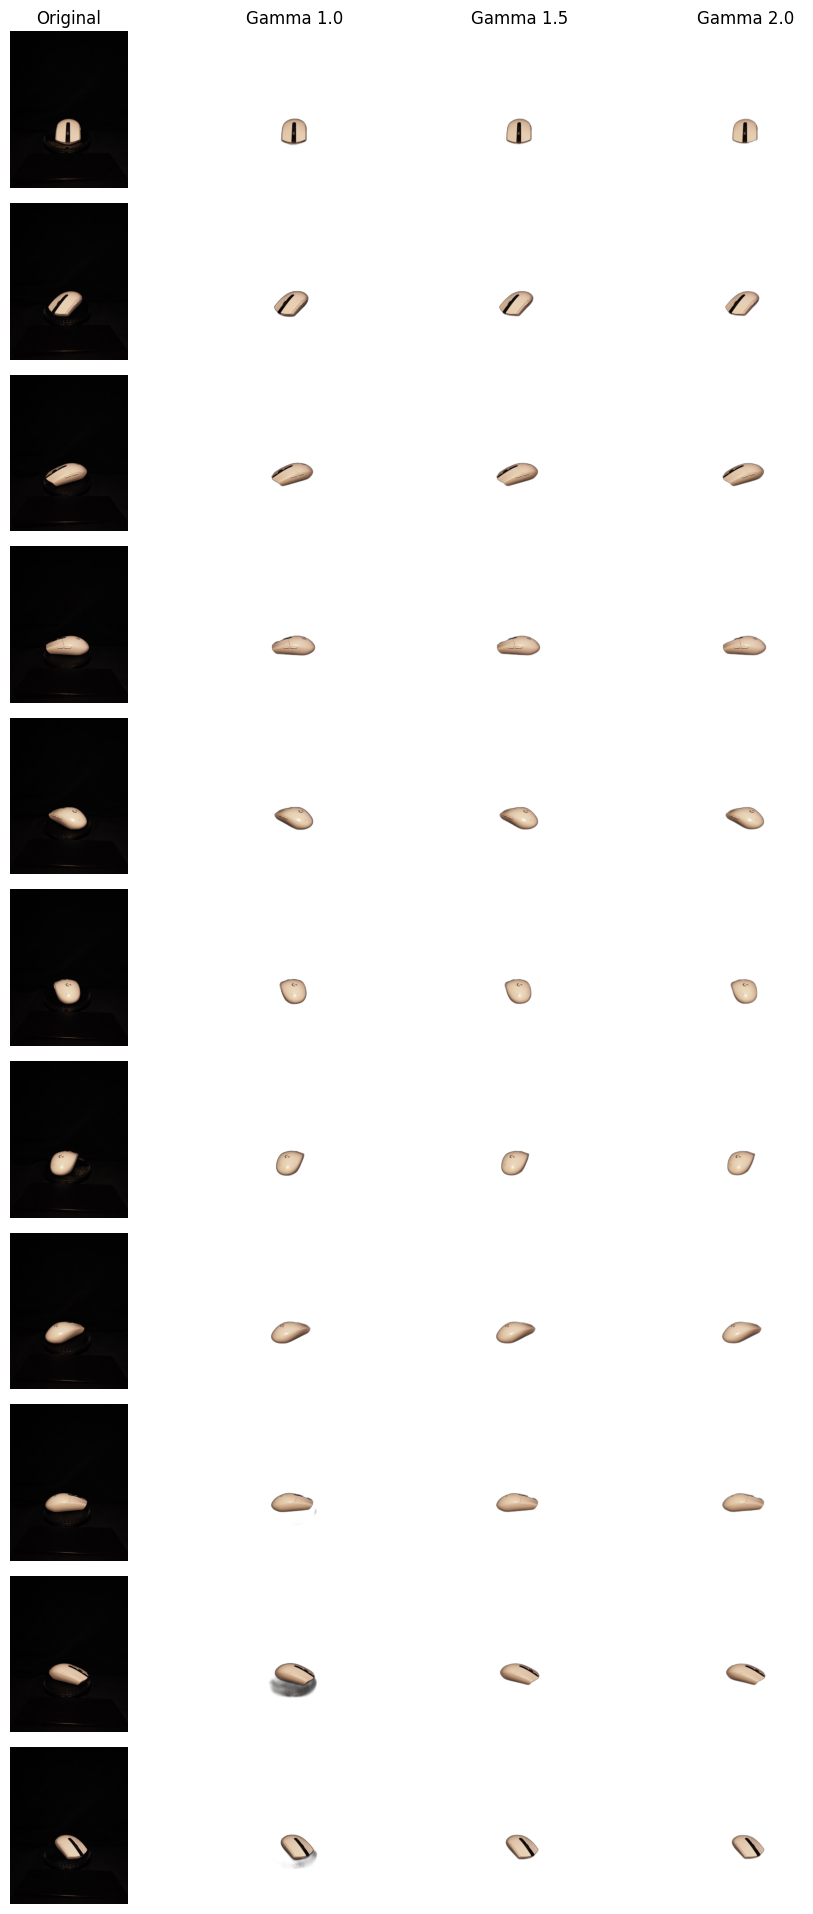

In [6]:
# Seleccionamos las imágenes para el test (solo RGB)
gammas = [1.0, 1.5, 2.0]

print('Iniciando benchmark de gammas...')

# Configuración del plot
fig, axes = plt.subplots(len(IMAGES), len(gammas) + 1, figsize=(10, 1.75 * len(IMAGES)))
for i, img_rgb in enumerate(IMAGES):
    # 1. Mostrar imagen original
    axes[i, 0].imshow(img_rgb)
    axes[i, 0].axis('off')
    if i == 0:
        axes[i, 0].set_title("Original")

    for j, g in enumerate(gammas):
        # 2. Eliminar fondo usando la función auxiliar con gamma integrado
        img_no_bg = remove_background(img_rgb, session, gamma=g)
        
        # 3. Mostrar resultado
        axes[i, j+1].imshow(img_no_bg)
        axes[i, j+1].axis('off')
        if i == 0:
            axes[i, j+1].set_title(f"Gamma {g}")

plt.tight_layout()
plt.show()

### Experimentación 2: Selección de Modelo de Segmentación (Opcional)

La librería `rembg` permite utilizar diferentes modelos de redes neuronales para la segmentación (ej. `u2net`, `u2netp`, `isnet-general-use`, `sam`).

Aunque el modelo por defecto (`u2net`) ofrece un excelente equilibrio entre calidad y rendimiento para objetos generales, en casos donde el objeto tiene detalles muy finos (como cabello o mallas) o un contraste muy bajo con el fondo, sería recomendable realizar un segundo benchmark comparando estos modelos.

Para este proyecto, tras la evaluación visual del benchmark de gamma, determinamos que **`u2net` con Gamma=2.0** proporciona resultados satisfactorios, por lo que procedemos con esta configuración.

### Ejecución del Pipeline de Preprocesado

Con los parámetros definidos (**Gamma = 2.0**), ejecutamos el procesamiento por lotes para todo el dataset.

El script iterará sobre todas las imágenes cargadas:
1.  Aplicará la eliminación de fondo con la configuración óptima.
2.  Convertirá el resultado al espacio de color BGRA (requerido por OpenCV para guardar).
3.  Guardará los archivos `.png` resultantes en el directorio de salida (`01_state` o similar), listos para la extracción de características.

In [14]:
# Fijamos el gamma elegido
GAMMA = 2.0
STATE_01 = '01_state'
IMAGES_BGLESS = []

PATH_01 = os.path.join(BASE_PATH, STATE_01)
os.makedirs(PATH_01, exist_ok=True)

print("Iniciando procesamiento...")

for i, img_rgba in enumerate(IMAGES):
    final_img = remove_background(img_rgba, session, gamma=GAMMA)
    IMAGES_BGLESS.append(final_img)
    
    filename = f"{i+1:02d}_model.png"
    out_path = os.path.join(PATH_01, filename)
    cv.imwrite(out_path, final_img)
    # Usamos end='\r' para sobrescribir la línea y evitar imprimir una lista larga
    print(f"|-> Procesada imagen: {filename}", end='\r')

print("") # Salto de línea final
print('Procesamiento completado.')

Iniciando procesamiento...
|-> Procesada imagen: 11_model.png
Procesamiento completado.
|-> Procesada imagen: 11_model.png
Procesamiento completado.


## Extracción y detección de características

### Algoritmo SIFT (Scale-Invariant Feature Transform)

Para la reconstrucción 3D, es fundamental encontrar puntos correspondientes ("matches") entre pares de imágenes consecutivas. Para ello, utilizamos el algoritmo **SIFT**, un estándar en visión por computador valorado por su gran robustez.

**¿Por qué usamos SIFT?**
A diferencia de otros detectores de esquinas simples, SIFT es capaz de detectar y describir características locales ("keypoints") que son invariantes a:
*   **Escala**: Reconoce el mismo detalle aunque el objeto esté más cerca o más lejos en la foto.
*   **Rotación**: Funciona correctamente aunque la cámara o el objeto hayan girado.
*   **Iluminación**: Es parcialmente invariante a cambios de luz y ruido.

**El flujo de trabajo implementado es:**

1.  **Detección de Keypoints**: Identificamos puntos de interés distintivos en ambas imágenes.
2.  **Cálculo de Descriptores**: Para cada punto, SIFT genera una "huella digital" numérica (vector de 128 valores) que describe la textura y gradientes a su alrededor.
3.  **Matching (Emparejamiento)**: Comparamos los descriptores de la *Imagen A* con los de la *Imagen B*. Utilizamos `BFMatcher` (Brute Force) con `knnMatch` ($k=2$) para encontrar los **dos** mejores candidatos para cada punto.
4.  **Filtrado (Lowe's Ratio Test)**: Para descartar falsos positivos, aplicamos la "Prueba de Razón de Lowe". Solo aceptamos un emparejamiento si la distancia al *mejor* candidato es significativamente menor (por ejemplo, $< 0.7$) que la distancia al *segundo mejor*. Esto elimina ambigüedades y asegura que el match es único y confiable.

In [8]:
def feature_and_matching(im1, im2):
    # Inicializa el detector SIFT (Scale-Invariant Feature Transform)
    # SIFT es robusto a cambios de escala y rotación.
    sift = cv.SIFT_create()

    # 1. Detección de Puntos Clave (Keypoints) y Descriptores
    # kp: Puntos clave (coordenadas, escala, orientación)
    # des: Descriptores (vector de 128 elementos que describen la región del keypoint)
    kp1, des1 = sift.detectAndCompute(im1, None)
    kp2, des2 = sift.detectAndCompute(im2, None)

    # 2. Emparejamiento de Descriptores (Feature Matching)
    # Inicializa el 'Brute-Force Matcher'.
    # Usamos FLANN o BFMatcher para encontrar la correspondencia más cercana entre descriptores.
    bf = cv.BFMatcher()

    # Aplica knnMatch (k=2) para encontrar los 2 mejores matches para cada descriptor.
    # Esto es necesario para la prueba del ratio de Lowe.
    matches = bf.knnMatch(des1, des2, k=2)
    
    # 3. Filtrado de Matches con el Test de Ratio de Lowe
    # Un match es "bueno" si la distancia al mejor match (m) es significativamente menor 
    # que la distancia al segundo mejor match (n).
    good_matches = []
    ratio_threshold = 0.7 # Valor común: 0.7 o 0.75
    
    for m, n in matches:
        if m.distance < n.distance * ratio_threshold:
            good_matches.append(m)

    # 4. Extracción de Coordenadas de los Puntos Emparejados
    matches = good_matches
    
    # pts1 y pts2 contienen las coordenadas (x, y) de los puntos emparejados, 
    # donde el punto en la posición "i" de pts1 está emparejado con el punto en la posición"i" de pts2.
    # Usamos np.float32 para la precisión geométrica y el formato (N, 2).

    pts1 = np.float32([kp1[p.queryIdx].pt for p in matches])
    pts2 = np.float32([kp2[p.trainIdx].pt for p in matches])

    # Devolvemos los puntos emparejados
    return pts1, pts2, kp1, kp2, good_matches


### Ejecución y Visualización del Matching

A continuación, probamos la función con dos imágenes consecutivas del dataset procesado. Visualizaremos las líneas que conectan los puntos clave encontrados en ambas imágenes para verificar visualmente la calidad de los emparejamientos. Si las líneas son paralelas y coherentes, el matching es correcto; si hay muchas líneas cruzadas caóticas, el filtrado necesita ajuste.

--- DATOS DEL MATCHING ---
Total puntos encontrados en Imagen 1: 296
Total puntos encontrados en Imagen 2: 286
Coincidencias (Matches) tras filtro:  21
Forma de la matriz de puntos 1:       (21, 2)
--------------------------


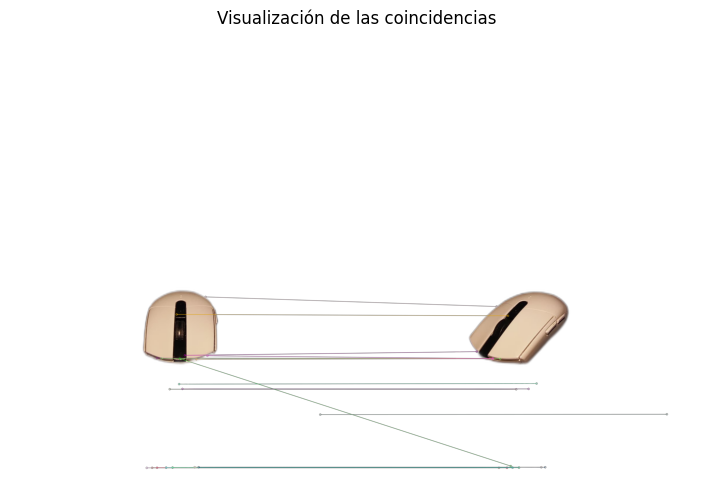

In [9]:
# 1. Seleccionamos dos imágenes
img1 = IMAGES_BGLESS[0]
img2 = IMAGES_BGLESS[1]

# 2. Ejecutamos tu función corregida
pts1, pts2, kp1, kp2, matches = feature_and_matching(img1, img2)

# --- DATOS QUE NOS INTERESAN ---
print(f"--- DATOS DEL MATCHING ---")
print(f"Total puntos encontrados en Imagen 1: {len(kp1)}")
print(f"Total puntos encontrados en Imagen 2: {len(kp2)}")
print(f"Coincidencias (Matches) tras filtro:  {len(matches)}")
print(f"Forma de la matriz de puntos 1:       {pts1.shape}") # Debería ser (N, 2)
print(f"--------------------------")

# 3. Visualización simple (Solo las primeras 50 líneas para ver claro)
res = cv.drawMatches(img1, kp1, img2, kp2, matches, None, flags=2)

plt.figure(figsize=(15, 6))
plt.title("Visualización de las coincidencias")
plt.imshow(res)
plt.axis('off')
plt.show()

## Sfm: Structure from Motion

Buscamos la matriz fundamental utilizando RANSAC y validamos de la Geometría Epipolar para ver si el emparejamiento hecho anteriormente tienen verdaderamente relación geometrica

In [10]:
# 1. Calculamos F y seleccionamos una muestra aleatoria
F, mask = cv.findFundamentalMat(pts1, pts2, cv.FM_RANSAC)

# Tomamos 10 índices al azar para no llenar la pantalla de rayas
import random
indices = random.sample(range(len(pts1)), 10)
p1_sample = pts1[indices]
p2_sample = pts2[indices]

# 2. Cálculo de líneas recíprocas
# Líneas en Img1 (correspondientes a puntos de Img2) -> whichImage=2
lines1 = cv.computeCorrespondEpilines(p2_sample.reshape(-1, 1, 2), 2, F).reshape(-1, 3)
# Líneas en Img2 (correspondientes a puntos de Img1) -> whichImage=1
lines2 = cv.computeCorrespondEpilines(p1_sample.reshape(-1, 1, 2), 1, F).reshape(-1, 3)

# 3. Función auxiliar de dibujo (reutilizable)
def dibujar_epilineas(img, lines, pts):
    h, w = img.shape[:2]
    out_img = cv.cvtColor(img, cv.COLOR_GRAY2RGB)
    
    for r, pt in zip(lines, pts):
        color = tuple(np.random.randint(0, 255, 3).tolist())
        # Dibujar línea: ax + by + c = 0  => y = -(c + ax)/b
        x0, y0 = 0, int(-r[2]/r[1])
        x1, y1 = w, int(-(r[2]+r[0]*w)/r[1])
        cv.line(out_img, (x0, y0), (x1, y1), color, 2)
        # Dibujar el punto (debe caer sobre la línea)
        cv.circle(out_img, tuple(int(x) for x in pt), 10, color, -1)
    return out_img

# 4. Visualización Recíproca
img1_epilines = dibujar_epilineas(img1, lines1, p1_sample) # Puntos en Img1 vs Líneas de Img2
img2_epilines = dibujar_epilineas(img2, lines2, p2_sample) # Puntos en Img2 vs Líneas de Img1

# Mostrar lado a lado
final_concat = np.hstack((img1_epilines, img2_epilines))

plt.figure(figsize=(20, 10))
plt.title("Test Recíproco: Izq (Pts1 sobre líneas de Pts2) | Der (Pts2 sobre líneas de Pts1)")
plt.imshow(final_concat)
plt.axis('off')
plt.show()

error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.simd_helpers.hpp:92: error: (-15:Bad number of channels) in function 'cv::impl::{anonymous}::CvtHelper<VScn, VDcn, VDepth, sizePolicy>::CvtHelper(cv::InputArray, cv::OutputArray, int) [with VScn = cv::impl::{anonymous}::Set<1>; VDcn = cv::impl::{anonymous}::Set<3, 4>; VDepth = cv::impl::{anonymous}::Set<0, 2, 5>; cv::impl::{anonymous}::SizePolicy sizePolicy = cv::impl::<unnamed>::NONE; cv::InputArray = const cv::_InputArray&; cv::OutputArray = const cv::_OutputArray&]'
> Invalid number of channels in input image:
>     'VScn::contains(scn)'
> where
>     'scn' is 4


Funcion donde se tiangula las posiciones de los puntos de 2 imagenes para calcular las posiciones 3D de dichas imagenes.

In [ ]:
def Sfm(im1, im2, focal_length=0, pixel_size=1):
 
    # 1. Obtener Puntos Emparejados
    pts1, pts2, _, _, _ = feature_and_matching(im1, im2)

    h, w = im1.shape[:2]
    
    # Si la longitud focal es 0, la inicializamos asumiendo una aproximación del sensor.
    if focal_length == 0:
        focal_length = np.maximum(h, w) 
    
    # 2. Definición de la Matriz Intrínseca de la Cámara (K)
    # En un caso real, K vendría de la calibración. 
    # Aquí asumimos fx = fy y que el centro óptico está en el centro de la imagen.
    
    # Si 20 es ya un valor en píxeles (ej. 2000), se usaría directamente.
    fx = focal_length / pixel_size
    fy = focal_length / pixel_size
    cx, cy = w / 2, h / 2
    
    K = np.array([[fx, 0, cx],
                  [0, fy, cy],
                  [0, 0, 1]])
    
    # 3. Estimación de la Matriz Esencial (E) y Filtro RANSAC
    # La Matriz Esencial relaciona la geometría epipolar entre dos vistas.
    # RANSAC filtra los puntos erróneos (outliers) para un cálculo robusto.
    # mask: Indica qué puntos pasaron el filtro RANSAC.
    E, mask = cv.findEssentialMat(pts1, pts2, K, method=cv.RANSAC, prob=0.99, threshold=1.0)

    # 4. Recuperación de la Pose (R, t)
    # Se descompone la matriz esencial para obtener la rotación (R) y traslación (t) 
    # que definen la pose de la segunda cámara relativa a la primera.
    # pose_mask: Filtra los puntos que tienen sentido físico (delante de ambas cámaras).
    _, R, t, pose_mask = cv.recoverPose(E, pts1, pts2, K)

    # 5. Definición de las Matrices de Proyección (P1 y P2)
    # P = K * [R | t]
    
    # La primera cámara (P1) está en el origen del sistema de coordenadas mundial.
    P1 = np.hstack((np.eye(3), np.zeros((3, 1)))) # P1 = K * [I | 0]
    P1 = K @ P1
    
    # La segunda cámara (P2) tiene la pose relativa R y t.
    P2 = np.hstack((R, t)) # P2 = K * [R | t]
    P2 = K @ P2

    # 6. Triangulación 3D
    # La triangulación encuentra la posición 3D (X, Y, Z, W) donde se cruzan los 
    # rayos de las dos cámaras para los puntos correspondientes.
    
    pts4d = cv.triangulatePoints(P1, P2, pts1.T, pts2.T)

    # 7. Conversión a Coordenadas Homogéneas (X, Y, Z)
    # Normalizamos por la coordenada W (última fila) para obtener las coordenadas 3D.
    pts3d = pts4d[:3] / pts4d[3]

    return pts3d.T.copy()


Test para calcular la nube de puntos generado por 2 imagenes

In [ ]:
# 1. Ejecutamos Sfm (usamos las imágenes 4 y 5 como ejemplo)
img1 = imgs_clean[0]
img2 = imgs_clean[1]
focal = max(img1.shape)
puntos_3d = Sfm(img1, img2, focal_length=focal)

# --- FASE DE LIMPIEZA Y FILTRADO AVANZADO ---
print(f"--- DATOS DE RECONSTRUCCIÓN (FILTRADO) ---")
print(f"Total puntos generados (inicial): {len(puntos_3d)}")

# 2. Paso Básico: Eliminar puntos nulos o infinitos (Errores de división/cálculo)
mascara_validos = np.isfinite(puntos_3d).any(axis=1)
puntos_limpios = puntos_3d[mascara_validos]
print(f"Puntos tras eliminar Inf/NaN: {len(puntos_limpios)}")

# 3. Paso Avanzado: Filtro de Percentil (Outlier Removal)
# Definimos los umbrales: 1% inferior y 99% superior (eliminamos el 2% más extremo)
p_low = 1  # 1% de los puntos más cercanos/negativos
p_high = 99 # 1% de los puntos más lejanos/positivos

# Calcular los umbrales de percentil para cada coordenada (X, Y, Z)
min_x, max_x = np.percentile(puntos_limpios[:, 0], [p_low, p_high])
min_y, max_y = np.percentile(puntos_limpios[:, 1], [p_low, p_high])
min_z, max_z = np.percentile(puntos_limpios[:, 2], [p_low, p_high])

# Crear una máscara que mantiene solo los puntos dentro de estos límites
filtro_percentil = (
    (puntos_limpios[:, 0] > min_x) & (puntos_limpios[:, 0] < max_x) &
    (puntos_limpios[:, 1] > min_y) & (puntos_limpios[:, 1] < max_y) &
    # Se aplica el filtro Z: los puntos deben estar en un rango positivo
    (puntos_limpios[:, 2] > 0) & (puntos_limpios[:, 2] < max_z) 
)

# Aplicar la máscara final
puntos_finales = puntos_limpios[filtro_percentil]

print(f"Rango de Profundidad (Z) Limpio: {puntos_finales[:, 2].min():.2f} a {puntos_finales[:, 2].max():.2f}")
print(f"Puntos finales después de filtrar: {len(puntos_finales)}")
print(f"---------------------------------------------------")

# 4. Visualización con graph_objects
fig = go.Figure(data=[go.Scatter3d(
    x=puntos_finales[:,0],
    y=puntos_finales[:,1],
    z=puntos_finales[:,2],
    mode='markers',
    marker=dict(
        size=3,
        color=puntos_finales[:,2], # Colorear por profundidad (Z)
        colorscale='Hot',          # Usamos otra escala de color para variar
        opacity=0.8
    )
)])

fig.update_layout(
    title="Nube de Puntos 3D Filtrada por Percentiles (Más Robusto)",
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z'
    ),
    margin=dict(l=0, r=0, b=0, t=30)
)

fig.show(renderer="iframe")

--- DATOS DE RECONSTRUCCIÓN (FILTRADO) ---
Total puntos generados (inicial): 24
Puntos tras eliminar Inf/NaN: 24
Rango de Profundidad (Z) Limpio: 2.80 a 34.13
Puntos finales después de filtrar: 20
---------------------------------------------------
